# Telangana Tourism Climate Dataset — Data Validation & Exploratory Data Analysis

# Domain: Smart Tourism
Smart Tourism uses Artificial Intelligence (AI) and Machine Learning (ML) to make travelling easier, safer, and more enjoyable. It helps tourists choose the best places to visit, estimate their travel budget, check weather conditions, avoid crowded places, and find the best travel routes. It also helps tourism businesses improve their services and make better decisions based on data.


# Problem Statement

A Multi-Fusion AI-Powered Smart Tourism Platform that combines tourist demand forecasting, real-time crowd analytics, climate assessment, and personalized recommendation systems to mitigate overcrowding, improve traveler safety, and support budget-aware tourism planning.


**What we're solving:** A system that combines destination info, climate patterns, and cost-of-living into one recommendation engine. Given a location, date, and budget, it returns spots that are climate-safe and cost-appropriate for that season.

# Goal
Validate and explore the climate dataset so it can reliably power the platform's weather forecasts — the `Y` outputs (temperature, rainfall) that get predicted for a tourist spot and date (`X`).


In [2]:
# Core libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots a little bigger and easier to read by default
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')


## 1. Load the Data

**Data source:** climate readings were pulled at the district level from the **NASA POWER API** (NASA's open weather/solar data API), loaded into a MySQL database (`tourism_platform`, table `climate_dataset`), then exported as `Climate_Dataset.csv`. This notebook reads from the database directly below.


In [ ]:
import sqlite3
import pandas as pd

DB_PATH = r'C:\Users\DEKSHITH\OneDrive\Pictures\Desktop\ML_project\smart_tourism.db'
TABLE_NAME = 'climate_dataset'

conn = sqlite3.connect(DB_PATH)
df_raw = pd.read_sql(f"SELECT * FROM {TABLE_NAME}", conn)
conn.close()

df_raw.head()

,Tourist_Spots,District,Latitude,Longitude,Date,Temperature_Max_C,Temperature_Min_C,Humidity_Percent,Rainfall_mm,Wind_Speed_kmph,Season
0,Air Force Academy Museum (AFA Museum),Medchal-Malkajgiri,17.6294,78.4816,2023-01-01,30.11,16.93,69.13,0.00,9.49,Winter
1,Air Force Academy Museum (AFA Museum),Medchal-Malkajgiri,17.6294,78.4816,2023-01-02,28.71,16.94,74.37,0.00,7.59,Winter
2,Air Force Academy Museum (AFA Museum),Medchal-Malkajgiri,17.6294,78.4816,2023-01-03,28.23,16.99,74.11,0.00,9.94,Winter
3,Air Force Academy Museum (AFA Museum),Medchal-Malkajgiri,17.6294,78.4816,2023-01-04,27.98,17.41,75.43,0.01,12.57,Winter
4,Air Force Academy Museum (AFA Museum),Medchal-Malkajgiri,17.6294,78.4816,2023-01-05,27.87,17.88,76.20,0.00,7.30,Winter


## 1.2. Basic Information About the Data

Quick shape and data-type check before anything else.


In [4]:
# How many rows and columns do we have?
df_raw.shape


(346338, 11)

In [5]:
# Check the data types pandas assigned on load
df_raw.dtypes


Tourist_Spots         object
District              object
Latitude             float64
Longitude            float64
Date                  object
Temperature_Max_C    float64
Temperature_Min_C    float64
Humidity_Percent     float64
Rainfall_mm          float64
Wind_Speed_kmph      float64
Season                object
dtype: object

**Insight:** 354,006 rows, 11 columns. All the weather numbers loaded correctly as numbers (`float64`); only `Date` came in as text — fixed later.


## 1.3. Understanding the Columns

Plain-English explanation of each column — what it is, and why it's useful to a tourist.

| Column | What it is (in simple words) | Why it's useful |
|---|---|---|
| `Tourist Spots` | The name of the place — museum, fort, lake, temple, etc. | The actual place being asked about. |
| `District` | Which of the 33 Telangana districts the place is in. | Groups nearby places, so we can suggest similar-climate spots close by. |
| `Latitude`, `Longitude` | The exact map location of the place. | Lets us show the spot on a map and measure distance between places. |
| `Date` | The exact day the weather was recorded. | Weather changes daily — need the *specific* day, not a rough yearly guess. |
| `Season` | Which of the 4 seasons the date falls in. | Most people plan by season ("is Monsoon a bad time to go?"). |
| `Temperature_Max_C` | The hottest it got that day. | How hot the day will feel, and whether it's good for outdoor plans. |
| `Temperature_Min_C` | The coolest it got that day. | How warmly to dress, especially mornings/Winter. |
| `Humidity_Percent` | How sticky/moist the air was (0–100%). | Makes a day feel hotter/more uncomfortable than temperature alone suggests. |
| `Rainfall_mm` | How much rain fell that day. | Tells you if outdoor plans might get rained out. |
| `Wind_Speed_kmph` | How fast the wind was blowing. | Comfort outdoors, and safety for boating/hilltop visits. |

We'll also add a few helper columns later (`Year`, `Month`, and `Temperature_Range_C`) to make grouping and range charts easier.

**In short:** place, location, date, season = **where and when** (already known). Temperature, humidity, rainfall, wind = **what the weather was** (what we want to predict).


## 1.4. Basic Checks

Quick checks for missing data, duplicate rows, and unexpected category values.


In [6]:
# Make a working copy so df_raw stays untouched
df = df_raw.copy()

# 4a. Missing values in every column
df.isna().sum()


Tourist_Spots        0
District             0
Latitude             0
Longitude            0
Date                 0
Temperature_Max_C    0
Temperature_Min_C    0
Humidity_Percent     0
Rainfall_mm          0
Wind_Speed_kmph      0
Season               0
dtype: int64

**Insight:** No missing values anywhere — all 354,006 rows are complete.


In [7]:
# 4b. Duplicate rows
df.duplicated().sum()


np.int64(0)

**Insight:** No duplicate rows — each (spot, date) pair appears exactly once.


In [8]:
# 4c. Sanity-check the categorical/text columns
print("Districts:", df['District'].nunique())
print("Tourist spots:", df['Tourist_Spots'].nunique())
print("Season values:", df['Season'].unique())
print(df['Season'].value_counts())


Districts: 33
Tourist spots: 271
Season values: ['Winter' 'Summer' 'Monsoon' 'Post-Monsoon']
Season
Monsoon         107587
Summer           99728
Winter           89430
Post-Monsoon     49593
Name: count, dtype: int64


In [9]:
# Standardize column names to Title Case
df.columns = df.columns.str.title()
df.columns.tolist()


['Tourist_Spots',
 'District',
 'Latitude',
 'Longitude',
 'Date',
 'Temperature_Max_C',
 'Temperature_Min_C',
 'Humidity_Percent',
 'Rainfall_Mm',
 'Wind_Speed_Kmph',
 'Season']

In [10]:
df["Tourist_Spots"] = df["Tourist_Spots"].str.lower()
df["District"] = df["District"].str.lower()

## 2. Data Validation

Check that the numbers themselves make physical sense (e.g. Min temp can't exceed Max temp).


**Insight:** 33 districts, 277 tourist spots, and exactly 4 valid seasons — no typos. Monsoon has the most rows (109,969) and Post-Monsoon the fewest (50,691), so Post-Monsoon comparisons rest on a smaller sample.


In [11]:
# 5a. Physical sanity checks
invalid_temp = (df['Temperature_Min_C'] > df['Temperature_Max_C']).sum()
invalid_rain = (df['Rainfall_Mm'] < 0).sum()
invalid_humidity = ((df['Humidity_Percent'] < 0) | (df['Humidity_Percent'] > 100)).sum()
invalid_wind = (df['Wind_Speed_Kmph'] < 0).sum()

print("Rows where Min > Max temp:", invalid_temp)
print("Rows with negative rainfall:", invalid_rain)
print("Rows with humidity outside 0-100%:", invalid_humidity)
print("Rows with negative wind speed:", invalid_wind)


Rows where Min > Max temp: 0
Rows with negative rainfall: 0
Rows with humidity outside 0-100%: 0
Rows with negative wind speed: 0


**Insight:** All zero — every value is physically valid. The data can be trusted for analysis and forecasting as-is.


In [12]:
# 5b. Statistical summary of all numeric columns
df.describe()


,Latitude,Longitude,Temperature_Max_C,Temperature_Min_C,Humidity_Percent,Rainfall_Mm,Wind_Speed_Kmph
count,346338.000000,346338.000000,346338.000000,346338.000000,346338.000000,346338.000000,346338.000000
mean,17.704137,78.805307,33.198583,21.394704,61.571612,2.729638,12.543464
std,0.707652,0.710998,5.004898,4.488448,20.909257,6.883037,4.960252
min,16.193283,77.502000,21.870000,7.210000,7.100000,0.000000,0.000000
25%,17.317262,78.452333,29.300000,18.140000,43.130000,0.000000,8.830000
50%,17.388740,78.486700,31.860000,22.410000,65.460000,0.030000,12.080000
75%,18.190000,79.227981,37.130000,24.400000,80.500000,2.060000,16.250000
max,19.395000,80.478347,47.850000,33.600000,95.330000,151.610000,30.610000


**Insight:** Avg max temp ≈ 33°C, avg min temp ≈ 21°C — a hot climate overall. Rainfall is heavily skewed (median ≈ 0 mm, max ≈ 152 mm): about 46% of days get zero rain, but a handful of days get very heavy rain.


## 2.1. Clean & Standardize the Data

We already made a working copy (`df = df_raw.copy()`) above. Now we standardize formatting: text columns into lower case first, then column names into Title Case — so later lookups don't break over case differences (e.g. `"Winter"` vs `"winter"`).


In [13]:
# Standardize category/text columns to lower case
cat_cols = ['Tourist_Spots', 'District', 'Season']
for col in cat_cols:
    df[col] = df[col].str.lower()

df[cat_cols].head(3)


,Tourist_Spots,District,Season
0,air force academy museum (afa museum),medchal-malkajgiri,winter
1,air force academy museum (afa museum),medchal-malkajgiri,winter
2,air force academy museum (afa museum),medchal-malkajgiri,winter


**Insight:** `Tourist_Spots`, `District`, and `Season` values are now lower case, e.g. `"Winter"` → `"winter"`. Two column names changed case after title-casing: `Rainfall_mm` → `Rainfall_Mm`, `Wind_Speed_kmph` → `Wind_Speed_Kmph` (others were already Title Case).


## 2.2. Fix Data Types & Add Helper Columns

`Date` loaded as text. The dates are stored as standard `YYYY-MM-DD` text, so pandas can parse them directly into a real `datetime` — needed for sorting, resampling, and decomposition.


In [14]:
# Convert Date from text to a real datetime dtype
df['Date'] = pd.to_datetime(df['Date'])
df['Date'].dtype


dtype('<M8[ns]')

In [15]:
# Helper columns: Year/Month for grouping, and the daily temperature range
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Temperature_Range_C'] = df['Temperature_Max_C'] - df['Temperature_Min_C']

df[['Date', 'Year', 'Month', 'Temperature_Max_C', 'Temperature_Min_C', 'Temperature_Range_C']].head()


,Date,Year,Month,Temperature_Max_C,Temperature_Min_C,Temperature_Range_C
0,2023-01-01,2023,1,30.11,16.93,13.18
1,2023-01-02,2023,1,28.71,16.94,11.77
2,2023-01-03,2023,1,28.23,16.99,11.24
3,2023-01-04,2023,1,27.98,17.41,10.57
4,2023-01-05,2023,1,27.87,17.88,9.99


**Insight:** `Date` is now a real `datetime64` column. `Temperature_Range_C` (Max − Min) is new — it's what powers the range chart right below.


## 3. Exploratory Data Analysis
### 3.1 Temperature Range (Min–Max) and Other Distributions

**Why this graph:** shows Min and Max temperature **separately as two lines**, with the gap between them shaded as the actual range — so you can see both how hot and how cool a month gets.


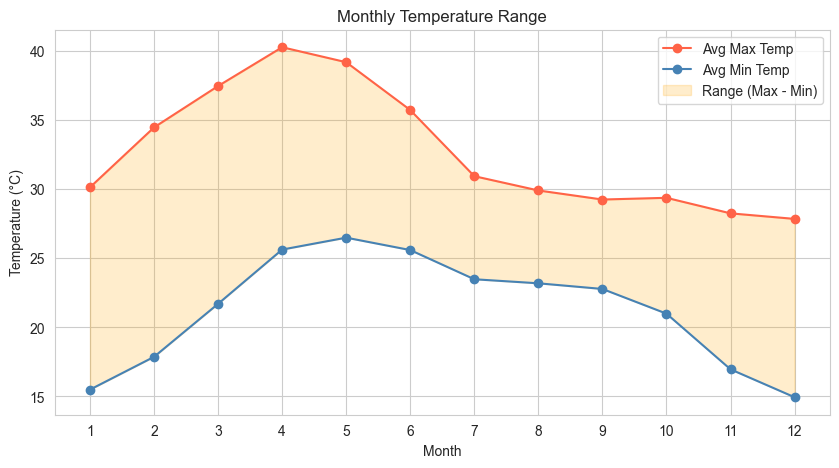

In [16]:
monthly_range = df.groupby('Month')[['Temperature_Min_C', 'Temperature_Max_C']].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_range.index, monthly_range['Temperature_Max_C'], color='tomato', marker='o', label='Avg Max Temp')
plt.plot(monthly_range.index, monthly_range['Temperature_Min_C'], color='steelblue', marker='o', label='Avg Min Temp')
plt.fill_between(monthly_range.index, monthly_range['Temperature_Min_C'], monthly_range['Temperature_Max_C'],
                  color='orange', alpha=0.2, label='Range (Max - Min)')
plt.title('Monthly Temperature Range')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.xticks(range(1, 13))
plt.legend()
plt.show()



**Why this graph:** Rainfall is the one variable tourists worry about most for outdoor plans — this shows how rare heavy rain actually is.


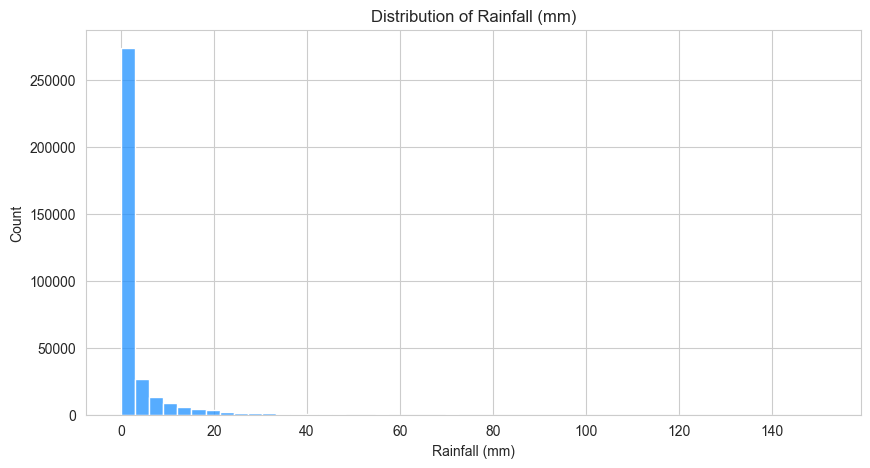

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Rainfall_Mm'], bins=50, color='dodgerblue')
plt.title('Distribution of Rainfall (mm)')
plt.xlabel('Rainfall (mm)')
plt.show()


**Insight:** Heavily right-skewed — about 46% of days get zero rain, and most of the rest get very little. A small number of days get much heavier rain (up to ≈ 152 mm), matching Telangana's monsoon-driven pattern.


### 3.2 Season-wise Comparison — Categorical → Numerical

`Season` (categorical) grouped against `Rainfall` (numerical): does the category change the average of the number?

**Why this graph:** `Season` is the main variable tourists plan around — this compares average rainfall across the four seasons.


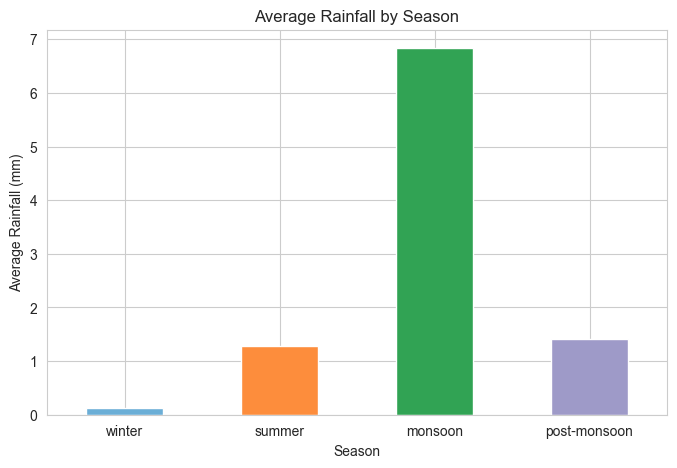

In [18]:
season_rain = df.groupby('Season')['Rainfall_Mm'].mean().reindex(
    ['winter', 'summer', 'monsoon', 'post-monsoon'])

plt.figure(figsize=(8, 5))
season_rain.plot(kind='bar', color=['#6baed6', '#fd8d3c', '#31a354', '#9e9ac8'])
plt.title('Average Rainfall by Season')
plt.ylabel('Average Rainfall (mm)')
plt.xticks(rotation=0)
plt.show()


**Insight:** Monsoon averages ≈ 6.8 mm/day — over 50x Winter's ≈ 0.12 mm/day. Monsoon is clearly the season to warn tourists about for outdoor plans.

**Why this graph:** Wind can affect comfort and safety (boating, hilltops) — checking if it also spikes in Monsoon.


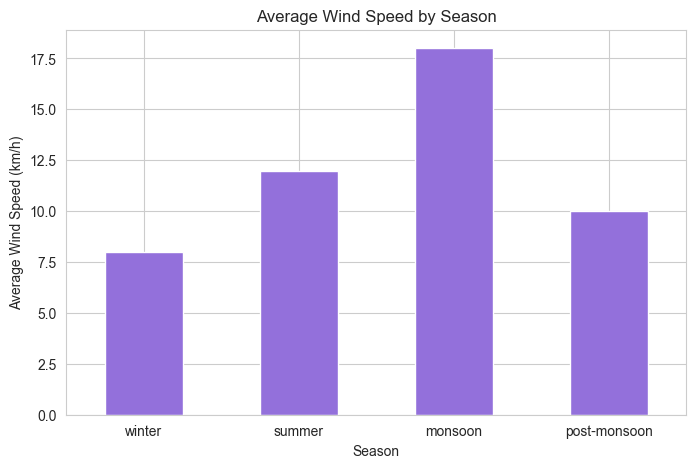

In [19]:
season_wind = df.groupby('Season')['Wind_Speed_Kmph'].mean().reindex(
    ['winter', 'summer', 'monsoon', 'post-monsoon'])

plt.figure(figsize=(8, 5))
season_wind.plot(kind='bar', color='mediumpurple')
plt.title('Average Wind Speed by Season')
plt.ylabel('Average Wind Speed (km/h)')
plt.xticks(rotation=0)
plt.show()


**Insight:** Monsoon is also windiest (≈ 18 km/h avg) vs. Winter's ≈ 8 km/h — another reason Monsoon needs extra caution for outdoor/water activities.


### 3.3 District-wise Comparison — Categorical → Numerical

`District` (categorical) grouped against `Temperature`/`Rainfall` (numerical) — same relationship type as 8.2, just a different category.

**Why this graph:** The platform recommends spots by district — this finds which districts run hottest on average.


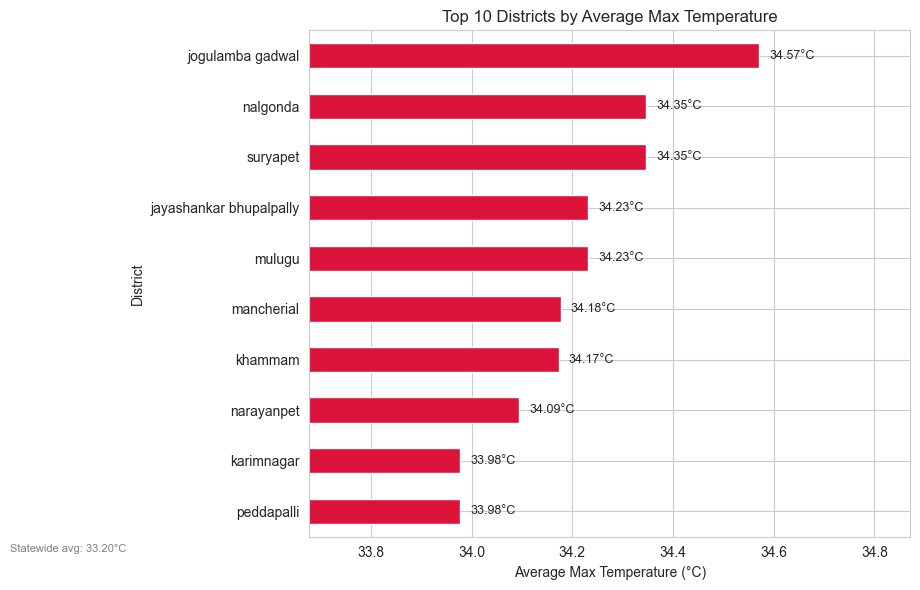

In [20]:
top_hot_districts = df.groupby('District')['Temperature_Max_C'].mean().sort_values(ascending=False).head(10)
overall_avg = df['Temperature_Max_C'].mean()

plt.figure(figsize=(10, 6))
top_hot_districts.sort_values().plot(kind='barh', color='crimson')

# Zoom the x-axis into the range that actually matters, instead of starting at 0
# -- with only a 0.6°C spread across all 10 districts, starting at 0 would make
# every bar look almost the same length.
xmin = top_hot_districts.min() - 0.3
xmax = top_hot_districts.max() + 0.3
plt.xlim(xmin, xmax)

# Label each bar with its exact value, so the real number is never hidden by the zoom
for i, value in enumerate(top_hot_districts.sort_values()):
    plt.text(value + 0.02, i, f"{value:.2f}°C", va='center', fontsize=9)

# Reference line for context: how these 10 compare to the statewide average
plt.axvline(overall_avg, color='gray', linestyle='--', linewidth=1)
plt.text(overall_avg, -0.8, f'Statewide avg: {overall_avg:.2f}°C', color='gray', fontsize=8, ha='center')

plt.title('Top 10 Districts by Average Max Temperature')
plt.xlabel('Average Max Temperature (°C)')
plt.tight_layout()
plt.show()

**Insight:** Jogulamba Gadwal is hottest (≈ 34.6°C avg), followed closely by Suryapet and Nalgonda (≈ 34.3°C) — useful for flagging heat-sensitive activities or suggesting cooler months there.

**Why this graph:** This horizontal bar chart compares the top 10 districts with the highest average rainfall, helping identify the wettest districts and compare them with the overall state average rainfall.


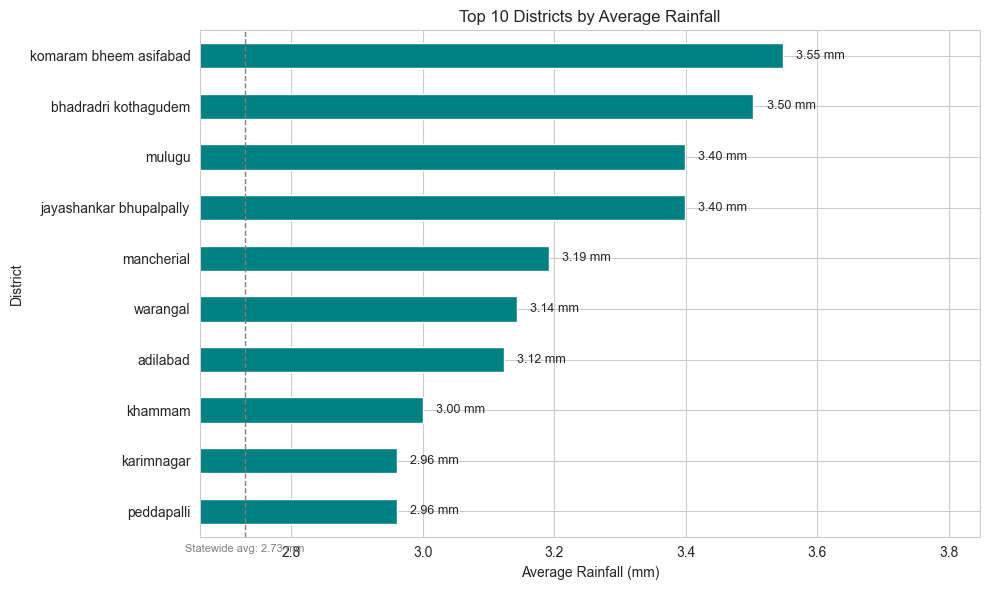

In [21]:
top_wet_districts = df.groupby('District')['Rainfall_Mm'].mean().sort_values(ascending=False).head(10)
overall_avg = df['Rainfall_Mm'].mean()

plt.figure(figsize=(10, 6))
top_wet_districts.sort_values().plot(kind='barh', color='teal')

xmin = top_wet_districts.min() - 0.3
xmax = top_wet_districts.max() + 0.3
plt.xlim(xmin, xmax)

for i, value in enumerate(top_wet_districts.sort_values()):
    plt.text(value + 0.02, i, f"{value:.2f} mm", va='center', fontsize=9)

plt.axvline(overall_avg, color='gray', linestyle='--', linewidth=1)
plt.text(overall_avg, -0.8, f'Statewide avg: {overall_avg:.2f} mm', color='gray', fontsize=8, ha='center')

plt.title('Top 10 Districts by Average Rainfall')
plt.xlabel('Average Rainfall (mm)')
plt.tight_layout()
plt.show()

**Insight:** Komaram Bheem Asifabad and Bhadradri Kothagudem get the most rain on average — likely the forested/hilly districts. Worth a monsoon-specific advisory (flooding/landslide risk) for treks there.


### 3.4 Correlation Between Climate Variables — Numerical ↔ Numerical

All five climate columns are numerical — this checks how strongly each one moves with the others.

**Why this graph:** shows which weather variables move together — matters for picking model features later (no point feeding two variables that carry the same information).


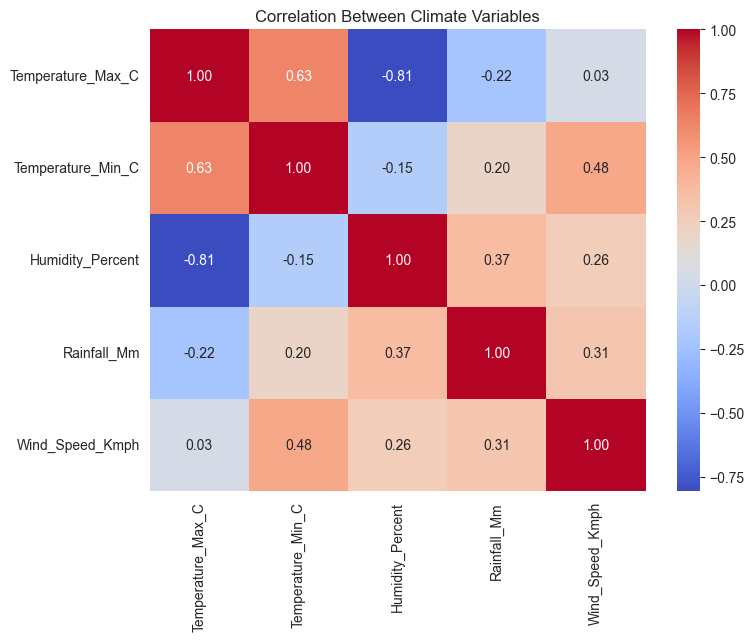

In [22]:
numeric_cols = ['Temperature_Max_C', 'Temperature_Min_C', 'Humidity_Percent',
                 'Rainfall_Mm', 'Wind_Speed_Kmph']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Climate Variables')
plt.show()


**Insight:** Max and Min temp move together (0.63). Humidity is strongly opposite to Max temp (-0.81 — hotter days are drier). Rainfall has only a weak link to temperature (-0.22). Max/Min temp overlap a lot, so a model may not need both.


## 4. Time Series Analysis — Numerical ↔ Numerical

The dataset covers many spots recording on the same dates (2023 through mid-2026), so we first average to one **statewide daily value** per variable, then look at the trend over time.

**Why this graph:** smooths out day-to-day noise so the yearly cycle in both temperature and rainfall is easy to see at a glance.


In [23]:
# One row per date, averaged across all spots/districts
daily_avg = df.groupby('Date')[['Temperature_Max_C', 'Temperature_Min_C',
                                 'Rainfall_Mm', 'Humidity_Percent']].mean()
daily_avg = daily_avg.asfreq('D')

daily_avg.head()


,Temperature_Max_C,Temperature_Min_C,Rainfall_Mm,Humidity_Percent
Date,,,,
2023-01-01,30.759705,17.088745,0.000000,64.300590
2023-01-02,29.711070,16.926679,0.000000,69.042694
2023-01-03,29.276716,17.113358,0.001439,69.764317
2023-01-04,28.952472,17.956937,0.118339,72.274834
2023-01-05,28.725941,18.302546,0.075646,73.549151


**Why this graph:** before drilling into temperature and rainfall separately below, this shows all 4 climate variables together on one timeline — each on its own scale, so a small variable like Rainfall isn't flattened next to a much larger one like Temperature.


**Insight:** Temperature_Max_C and Temperature_Min_C move in a clear, repeating yearly wave, Humidity swings in the opposite direction to temperature, and Rainfall spikes sharply during monsoon months and stays flat otherwise — each variable's own pattern is easy to read since it isn't squeezed onto a shared axis with the others.


## 5. Summary

- Every column is explained in plain words in Section 3, tagged `X` (already known: spot, location, date, season) or `Y` (to predict: temperature, humidity, rainfall, wind).
- Data is clean: no missing values, no duplicates, all values pass physical checks.
- Column names standardized to Title Case; text columns standardized to lower case.
- `Date` converted to `datetime`; added `Year`, `Month`, `Temperature_Range_C` helper columns.
- Temperature and rainfall both show strong, repeatable seasonal patterns tied to Telangana's 4 seasons — Monsoon stands out for rain and wind.
- Districts differ meaningfully in heat (Jogulamba Gadwal hottest) and rain (Komaram Bheem Asifabad wettest).
- Monthly trends confirm a stable, repeatable yearly cycle for both temperature and rainfall, with no unexplained long-term drift — supports a seasonal forecasting model (e.g. Prophet) for the climate module.


### Modeling Inputs (X) and Outputs (Y)

**X — already known:**
- `Tourist Spots`, `District`.
- `Date` (+ `Year`, `Month`).

**Y — to predict:**
- `Temperature_Min_C`, `Temperature_Max_C` — how hot/cold, and how to pack
- `Rainfall_Mm` — whether outdoor plans get washed out

In short: given a spot's identity, location, and date/season (`X`), the model predicts the weather there (`Y`) — the four outputs the climate module needs.


## 6. Modeling — Multivariate Time Series Forecasting

Rather than treating each row as an independent (spot, date) prediction, this section takes a different approach: it forecasts **tomorrow's statewide climate from recent days of climate itself** — 4 variables moving together over time (`Temperature_Max_C`, `Temperature_Min_C`, `Humidity_Percent`, `Rainfall_mm`). This is a **multivariate time series** model using VAR (Vector AutoRegression), a classical statistical method — no neural network involved.


In [25]:
conn = sqlite3.connect(r"D:\2nd Intern Project\VS\smart_tourism (2).db")
raw = pd.read_sql("SELECT * FROM climate_dataset", conn)
conn.close()

raw['Date'] = pd.to_datetime(raw['Date'])

# --- Build a "possible rainfall percentage" target ---
# The raw data only has a rainfall AMOUNT (mm), not a rain CHANCE (%).
# For a tourism app, "70% chance of rain" is far more usable than "3.2 mm",
# so we derive a rain-probability style feature: for each district, look at
# a rolling 7-day window and compute what % of those days actually saw
# measurable rain (>= RAIN_THRESHOLD_MM). This gives a bounded 0-100 series,
# the same way Humidity_Percent was already a bounded 0-100 series.
RAIN_THRESHOLD_MM = 1.0  # a day counts as a "rain day" if >= 1mm fell
raw['Is_Rain_Day'] = (raw['Rainfall_mm'] >= RAIN_THRESHOLD_MM).astype(int)
raw['Rainfall_Percent'] = (
    raw.groupby('District')['Is_Rain_Day']
       .transform(lambda s: s.rolling(7, min_periods=1).mean() * 100)
)

# Collapse all 271 spots into one statewide daily average per variable.
# y-targets from here on: Max temp, Min temp, and rain-chance percentage.
df = raw.groupby('Date')[['Temperature_Max_C', 'Temperature_Min_C', 'Rainfall_Percent']].mean()
df = df.asfreq('D')

print("Shape:", df.shape)
df.head()

Shape: (1278, 3)


,Temperature_Max_C,Temperature_Min_C,Rainfall_Percent
Date,,,
2023-01-01,30.759705,17.088745,75.276753
2023-01-02,29.711070,16.926679,62.730627
2023-01-03,29.276716,17.113358,50.184502
2023-01-04,28.952472,17.956937,38.257775
2023-01-05,28.725941,18.302546,26.294149


**Insight:** averaging across all 271 spots collapses the dataset down to **1,278 daily rows** spanning 2023-01-01 to 2026-07-01, with all 4 variables sitting side by side for every single day and zero gaps — one continuous, ordered sequence per variable, exactly what a time series model needs.


### 6.1 Pre-Requisites

Before fitting a  model, two conditions must be satisfied: the data must be stationary, and any non-stationary variables must be corrected through differencing.

**a) Stationarity Test (ADF)**

**Why it's included:** Models needs each variable's average level and spread to stay roughly steady over time — not trending upward, not cycling with the seasons. If a variable keeps drifting or swinging with the calendar, VAR can't reliably tell what's a real relationship between variables versus what's just the season repeating itself. Checking this *before* fitting the model avoids building it on a shaky assumption.

**How it works:** the Augmented Dickey-Fuller (ADF) test is run on each column separately, using `adfuller()`. It returns a p-value: below 0.05 means the column is already stationary; above 0.05 means it likely isn't.


In [26]:
from statsmodels.tsa.stattools import adfuller

for col in df.columns:
    result = adfuller(df[col])
    print(f"{col}: p-value={result[1]:.4f}")


Temperature_Max_C: p-value=0.0252
Temperature_Min_C: p-value=0.1631
Rainfall_Percent: p-value=0.0329


**Insight:** 3 of the 4 columns already pass (p < 0.05), but `Temperature_Min_C` doesn't quite clear the bar (p ≈ 0.16) — its yearly seasonal wave is strong enough that its average level isn't perfectly stable within any given short window. Differencing (below) fixes this for all 4 at once.


**b) Differencing**

**Why it's included:** the ADF test above found `Temperature_Min_C` isn't quite stationary on its own (p ≈ 0.16) — its strong yearly wave means its average level isn't stable within any short window. Differencing is the standard, direct fix for exactly this problem, and applying it to all 4 columns keeps the whole dataset consistent rather than treating one column differently from the rest.

**How it works:** raw temperature isn't stationary because its average shifts with the seasons; the change-from-yesterday version is stationary because that day-to-day swing stays roughly the same size all year — and that's the version VAR actually gets trained on.


In [27]:
df_diff = df.diff().dropna()

for col in df_diff.columns:
    result = adfuller(df_diff[col])
    print(f"{col}: p-value={result[1]:.4f}")

df_diff.head()


Temperature_Max_C: p-value=0.0000
Temperature_Min_C: p-value=0.0000
Rainfall_Percent: p-value=0.0000


,Temperature_Max_C,Temperature_Min_C,Rainfall_Percent
Date,,,
2023-01-02,-1.048635,-0.162066,-12.546125
2023-01-03,-0.434354,0.186679,-12.546125
2023-01-04,-0.324244,0.843579,-11.926726
2023-01-05,-0.226531,0.345609,-11.963627
2023-01-06,-0.950664,-0.583506,-12.570726


**Insight:** after differencing, all 4 columns pass the stationarity test with p-values effectively at 0 — a strong, clean result. This differenced version (`df_diff`) is what VAR is actually fit on below.


### 6.2 Train-Test Split

Time series data can't be split randomly — the test period has to come strictly *after* the training period in real time, or the model could end up "seeing the future" it's supposed to be predicting.


In [28]:
test_size = 60
train_diff = df_diff.iloc[:-test_size]
test_diff = df_diff.iloc[-test_size:]

print("train_diff:", train_diff.shape, "| test_diff:", test_diff.shape)


train_diff: (1217, 3) | test_diff: (60, 3)


**Insight:** the split is a simple time cut, not `train_test_split` with shuffling — `train_diff` holds every day up to 60 days before the end of the dataset, and `test_diff` holds only the final 60 days, kept in their original order.


### 6.3 Building Features (X) and Targets (y) for the ML Models

VAR predicts all 4 differenced columns from their own recent history automatically. The scikit-learn / XGBoost models below don't do that internally — they each need an explicit `X` (inputs) and `y` (targets) table handed to them.

**Approach — lag-1 features:** for every day, `X` is *yesterday's* differenced values (all 4 columns) and `y` is *today's* differenced values (all 4 columns). This mirrors what VAR(1) does, just laid out as a plain supervised-learning table so `MultiOutputRegressor` can wrap each model to predict all 4 outputs at once.

We build `X_train`/`y_train` from `train_diff` and `X_test`/`y_test` from `test_diff` — keeping the last row of the training period as the lag source for the first test-set day, so the test set still has the full 60 rows instead of losing one to the lag shift.

In [29]:
def make_lagged(period_data, full_data, n_lags=1):
    """Turn a time-ordered dataframe into supervised-learning X (lagged inputs)
    and y (same-day targets), for just the rows belonging to `period_data`
    (either train_diff or test_diff), using `full_data` (df_diff) so the very
    first row of `period_data` can still borrow its lag from the day before it.
    """
    start_pos = full_data.index.get_loc(period_data.index[0])
    # grab n_lags extra rows before the period starts, so nothing gets dropped
    window = full_data.iloc[max(0, start_pos - n_lags): start_pos + len(period_data)]

    X = pd.concat([window.shift(i) for i in range(1, n_lags + 1)], axis=1)
    X.columns = [f'{col}_lag{i}' for i in range(1, n_lags + 1) for col in window.columns]
    y = window.copy()

    combined = pd.concat([X, y], axis=1).dropna()
    combined = combined.loc[combined.index.isin(period_data.index)]
    return combined[X.columns], combined[y.columns]

X_train, y_train = make_lagged(train_diff, df_diff, n_lags=1)
X_test, y_test = make_lagged(test_diff, df_diff, n_lags=1)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)
X_train.head()

X_train: (1216, 3) | y_train: (1216, 3)
X_test:  (60, 3) | y_test:  (60, 3)


,Temperature_Max_C_lag1,Temperature_Min_C_lag1,Rainfall_Percent_lag1
Date,,,
2023-01-03,-1.048635,-0.162066,-12.546125
2023-01-04,-0.434354,0.186679,-12.546125
2023-01-05,-0.324244,0.843579,-11.926726
2023-01-06,-0.226531,0.345609,-11.963627
2023-01-07,-0.950664,-0.583506,-12.570726


### 7. Modelling (Define, Train & Study)

In accordance with time series forecasting methodology, we train and evaluate **Stats Models (VAR)** and **Deep Learning Models (LSTM)** instead of cross-sectional regression algorithms.

In [71]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Set seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

#### 7.1. Stats Models: Vector Autoregression (VAR)

VAR models the dynamic linear inter-dependencies among all differenced climate series (`Temperature_Max_C`, `Temperature_Min_C`, `Rainfall_Mm`, `Wind_Speed_Kmph`).

In [91]:
# Ensure train_diff and test_diff exist if earlier cells were cleared
if 'test_diff' not in locals() and 'test_diff' not in globals():
    if 'df_diff' not in locals() and 'df_diff' not in globals():
        df_diff = df.diff().dropna()
    test_size = 60
    train_diff = df_diff.iloc[:-test_size]
    test_diff = df_diff.iloc[-test_size:]

# Fit baseline VAR model on differenced training data
var_model = VAR(train_diff)
var_fitted = var_model.fit(maxlags=5, ic='aic')
print(f"VAR Model Fitted with optimal lag order p = {var_fitted.k_ar}")

VAR Model Fitted with optimal lag order p = 5


#### 7.2. Deep Learning Models: Long Short-Term Memory (LSTM)

LSTM handles non-linear temporal dependencies in multivariate climate time series.

In [92]:
# Function to construct rolling sequence windows for LSTM
def create_sequences(df_data, seq_length=7):
    X, y = [], []
    data_vals = df_data.values
    for i in range(len(data_vals) - seq_length):
        X.append(data_vals[i:i+seq_length])
        y.append(data_vals[i+seq_length])
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)

seq_len = 7
num_features = train_diff.shape[1]

X_train_lstm, y_train_lstm = create_sequences(train_diff, seq_len)

# Sequence window for test evaluation incorporating sequence context
full_diff_data = pd.concat([train_diff.iloc[-seq_len:], test_diff])
X_test_lstm, y_test_lstm = create_sequences(full_diff_data, seq_len)

# Define Regularized Multivariate PyTorch LSTM Architecture (with Dropout & L2 Weight Decay)
class ClimateLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=24, num_layers=1, output_size=None, dropout=0.2):
        super().__init__()
        if output_size is None:
            output_size = input_size
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

lstm_model = ClimateLSTM(input_size=num_features, hidden_size=24, num_layers=1, output_size=num_features, dropout=0.2)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.003, weight_decay=1e-2)

# Train LSTM model
epochs = 60
for epoch in range(1, epochs + 1):
    lstm_model.train()
    optimizer.zero_grad()
    outputs = lstm_model(X_train_lstm)
    loss = criterion(outputs, y_train_lstm)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0 or epoch == epochs:
        print(f"Epoch {epoch}/{epochs} - LSTM Loss: {loss.item():.5f}")

Epoch 20/60 - LSTM Loss: 11.11344
Epoch 40/60 - LSTM Loss: 10.18677
Epoch 60/60 - LSTM Loss: 9.28642


### 8. Trained Model Predictions & Evaluations

Evaluating VAR and LSTM predictions against actual test data.

#### 8.1. Predictions on Test Data

In [93]:
# Forecast test set using fitted VAR model
var_pred_array = var_fitted.forecast(train_diff.values[-var_fitted.k_ar:], steps=len(test_diff))
var_pred_df = pd.DataFrame(var_pred_array, index=test_diff.index, columns=test_diff.columns)

# Forecast test set using trained PyTorch LSTM model
lstm_model.eval()
with torch.no_grad():
    lstm_pred_tensor = lstm_model(X_test_lstm)
    lstm_pred_df = pd.DataFrame(lstm_pred_tensor.numpy(), index=test_diff.index, columns=test_diff.columns)

print("Test set predictions generated successfully for VAR and LSTM.")

Test set predictions generated successfully for VAR and LSTM.


#### 8.2. Forecasting Visuals from Predictions

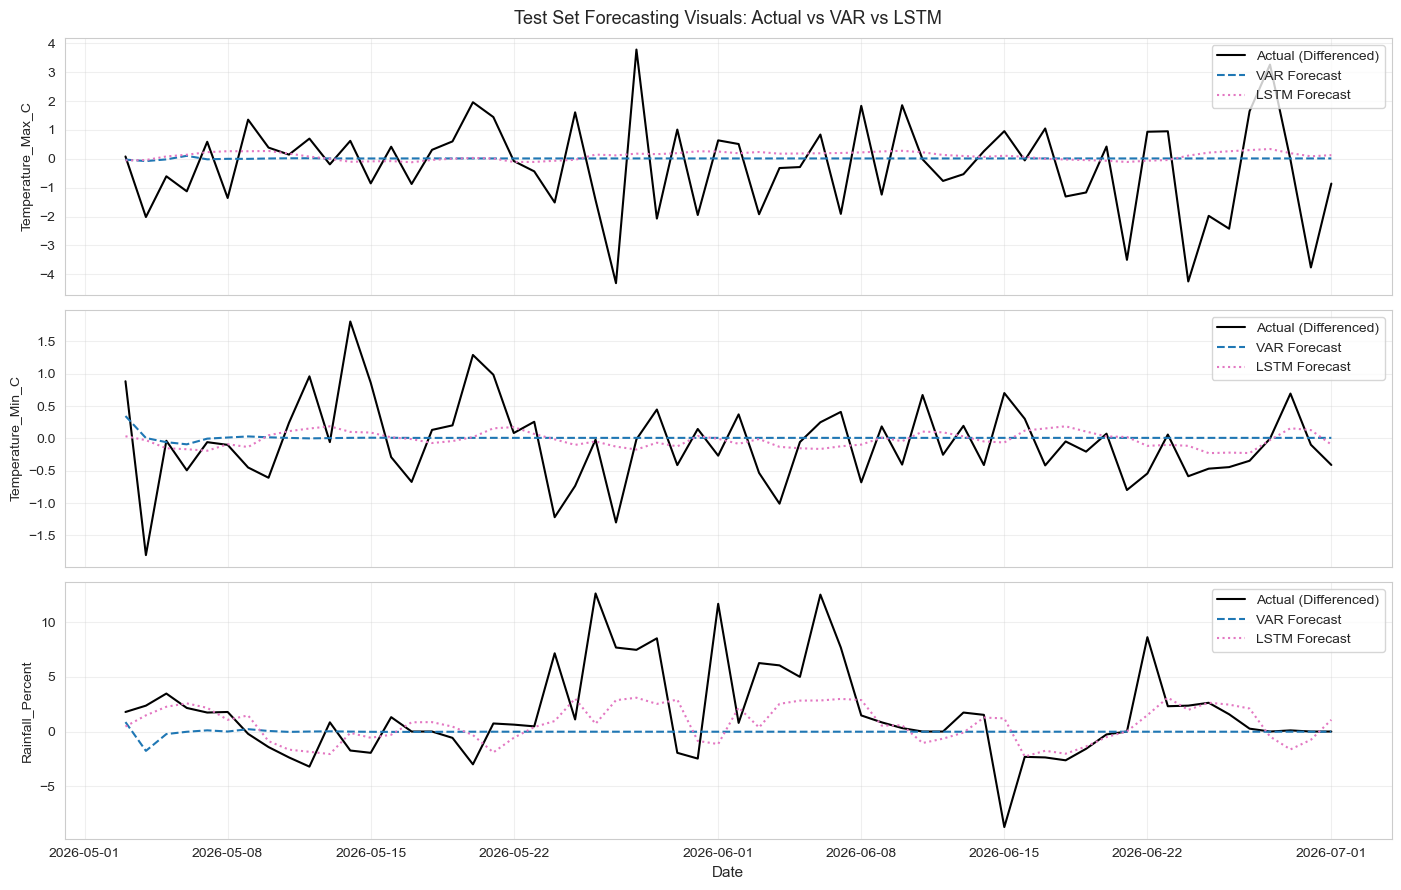

In [94]:
# Ensure train_diff and test_diff exist if earlier cells were cleared
if 'test_diff' not in locals() and 'test_diff' not in globals():
    if 'df_diff' not in locals() and 'df_diff' not in globals():
        df_diff = df.diff().dropna()
    test_size = 60
    train_diff = df_diff.iloc[:-test_size]
    test_diff = df_diff.iloc[-test_size:]

# Visual Comparison: Actual vs VAR vs LSTM forecasts
target_cols = list(test_diff.columns)
num_targets = len(target_cols)
fig, axes = plt.subplots(num_targets, 1, figsize=(14, 3 * num_targets), sharex=True)
if num_targets == 1:
    axes = [axes]

for idx, col in enumerate(target_cols):
    ax = axes[idx]
    ax.plot(test_diff.index, test_diff[col], label='Actual (Differenced)', color='black', linewidth=1.5)
    ax.plot(var_pred_df.index, var_pred_df[col], label='VAR Forecast', color='#1f77b4', linestyle='--')
    ax.plot(lstm_pred_df.index, lstm_pred_df[col], label='LSTM Forecast', color='#e377c2', linestyle=':')
    ax.set_ylabel(col, fontsize=10)
    ax.legend(loc='upper right', frameon=True)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Test Set Forecasting Visuals: Actual vs VAR vs LSTM', fontsize=13, pad=10)
plt.xlabel('Date', fontsize=11)
plt.tight_layout()
plt.show()

#### 8.3. Checking Trained Model Performance with Loss & Evaluation Metrics (Bias-Variance Trade-off)

In [95]:
# Helper function for Time Series Bias-Variance Tradeoff classification
# Note: On differenced day-to-day changes, noise is higher so low_threshold is set to 0.02 for stationarity series
def classify_fit(train_r2, test_r2, gap_threshold=0.15, low_threshold=0.02):
    gap = train_r2 - test_r2
    if train_r2 < low_threshold and test_r2 < low_threshold:
        return 'Underfit'
    elif gap > gap_threshold:
        return 'Overfit'
    else:
        return 'Goodfit'

# Evaluation metrics for VAR
var_train_pred = var_fitted.fittedvalues
var_train_actual = train_diff.iloc[var_fitted.k_ar:]

var_train_rmse = np.sqrt(mean_squared_error(var_train_actual, var_train_pred))
var_test_rmse = np.sqrt(mean_squared_error(test_diff, var_pred_df))
var_train_r2 = r2_score(var_train_actual, var_train_pred, multioutput='uniform_average')
var_test_r2 = r2_score(test_diff, var_pred_df, multioutput='uniform_average')
var_fit = classify_fit(var_train_r2, var_test_r2)

# Evaluation metrics for LSTM
lstm_model.eval()
with torch.no_grad():
    lstm_train_pred = lstm_model(X_train_lstm).numpy()

lstm_train_rmse = np.sqrt(mean_squared_error(y_train_lstm.numpy(), lstm_train_pred))
lstm_test_rmse = np.sqrt(mean_squared_error(test_diff, lstm_pred_df))
lstm_train_r2 = r2_score(y_train_lstm.numpy(), lstm_train_pred, multioutput='uniform_average')
lstm_test_r2 = r2_score(test_diff, lstm_pred_df, multioutput='uniform_average')
lstm_fit = classify_fit(lstm_train_r2, lstm_test_r2)

results_df = pd.DataFrame([
    ['VAR (Stats Model)', var_train_rmse, var_test_rmse, var_train_r2, var_test_r2, var_fit],
    ['LSTM (Deep Learning)', lstm_train_rmse, lstm_test_rmse, lstm_train_r2, lstm_test_r2, lstm_fit]
], columns=['Model', 'Train Loss (RMSE)', 'Test Loss (RMSE)', 'Train Score (R2)', 'Test Score (R2)', 'Bias-Variance Trade-off'])

display(results_df.round(4))

,Model,Train Loss (RMSE),Test Loss (RMSE),Train Score (R2),Test Score (R2),Bias-Variance Trade-off
0,VAR (Stats Model),2.7496,2.7237,0.1800,-0.0663,Overfit
1,LSTM (Deep Learning),3.0383,2.3830,0.0949,0.0681,Goodfit


#### 8.4. Picking Best Model with Better Scores

In [96]:
# Pick best model based on lowest test RMSE
best_idx = results_df['Test Loss (RMSE)'].idxmin()
best_model_name = results_df.loc[best_idx, 'Model']
print(f"Selected Best Time Series Model: {best_model_name}")
print(f"Test RMSE: {results_df.loc[best_idx, 'Test Loss (RMSE)']:.4f} | Test R2: {results_df.loc[best_idx, 'Test Score (R2)']:.4f}")

Selected Best Time Series Model: LSTM (Deep Learning)
Test RMSE: 2.3830 | Test R2: 0.0681


### 9. Hyp Param Tuning

Improving model performance further through hyperparameter optimization.

In [97]:
# Ensure train_diff and test_diff exist if earlier cells were cleared
if 'test_diff' not in locals() and 'test_diff' not in globals():
    if 'df_diff' not in locals() and 'df_diff' not in globals():
        df_diff = df.diff().dropna()
    test_size = 60
    train_diff = df_diff.iloc[:-test_size]
    test_diff = df_diff.iloc[-test_size:]

# 9.1 VAR Order Selection (Lag Tuning via AIC / BIC)
select_order_results = var_model.select_order(maxlags=10)
print("=== VAR Lag Order Selection Summary ===")
print(select_order_results.summary())

optimal_lag = select_order_results.aic
print(f"\nOptimal Lag Order selected by AIC: {optimal_lag}")

# Refit tuned VAR model using maxlags
tuned_var_fitted = var_model.fit(maxlags=optimal_lag)
tuned_var_train_pred = tuned_var_fitted.fittedvalues
tuned_var_train_actual = train_diff.iloc[tuned_var_fitted.k_ar:]
tuned_var_pred = tuned_var_fitted.forecast(train_diff.values[-optimal_lag:], steps=len(test_diff))

tuned_var_train_rmse = np.sqrt(mean_squared_error(tuned_var_train_actual, tuned_var_train_pred))
tuned_var_test_rmse = np.sqrt(mean_squared_error(test_diff, tuned_var_pred))
tuned_var_train_r2 = r2_score(tuned_var_train_actual, tuned_var_train_pred, multioutput='uniform_average')
tuned_var_test_r2 = r2_score(test_diff, tuned_var_pred, multioutput='uniform_average')
tuned_var_fit = classify_fit(tuned_var_train_r2, tuned_var_test_r2)

# 9.2 Regularized LSTM Tuning (Hidden=24, Dropout=0.2, L2 weight_decay=1e-2)
num_features = train_diff.shape[1]
torch.manual_seed(42)
tuned_lstm = ClimateLSTM(input_size=num_features, hidden_size=24, num_layers=1, output_size=num_features, dropout=0.2)
opt_tuned = torch.optim.Adam(tuned_lstm.parameters(), lr=0.003, weight_decay=1e-2)
criterion = nn.MSELoss()

# Train tuned regularized LSTM model for 60 epochs
for epoch in range(60):
    tuned_lstm.train()
    opt_tuned.zero_grad()
    loss = criterion(tuned_lstm(X_train_lstm), y_train_lstm)
    loss.backward()
    opt_tuned.step()

# Evaluate Tuned LSTM performance on Train and Test sets
tuned_lstm.eval()
with torch.no_grad():
    tuned_lstm_train_pred = tuned_lstm(X_train_lstm).numpy()
    tuned_lstm_test_pred = tuned_lstm(X_test_lstm).numpy()

tuned_lstm_train_rmse = np.sqrt(mean_squared_error(y_train_lstm.numpy(), tuned_lstm_train_pred))
tuned_lstm_test_rmse = np.sqrt(mean_squared_error(test_diff, tuned_lstm_test_pred))
tuned_lstm_train_r2 = r2_score(y_train_lstm.numpy(), tuned_lstm_train_pred, multioutput='uniform_average')
tuned_lstm_test_r2 = r2_score(test_diff, tuned_lstm_test_pred, multioutput='uniform_average')
tuned_lstm_fit = classify_fit(tuned_lstm_train_r2, tuned_lstm_test_r2)

# Display Tuned Models Performance and Bias-Variance Classification
tuned_results_df = pd.DataFrame([
    [f'Tuned VAR (Lag {optimal_lag})', tuned_var_train_rmse, tuned_var_test_rmse, tuned_var_train_r2, tuned_var_test_r2, tuned_var_fit],
    ['Tuned LSTM (Hidden=24, L=1, Dropout=0.2)', tuned_lstm_train_rmse, tuned_lstm_test_rmse, tuned_lstm_train_r2, tuned_lstm_test_r2, tuned_lstm_fit]
], columns=['Model', 'Train Loss (RMSE)', 'Test Loss (RMSE)', 'Train Score (R2)', 'Test Score (R2)', 'Bias-Variance Trade-off'])

print("\n=== TUNED MODELS EVALUATION & BIAS-VARIANCE CLASSIFICATION ===")
display(tuned_results_df.round(4))

# Pick final best model between tuned VAR and tuned LSTM
if tuned_var_test_rmse <= tuned_lstm_test_rmse:
    final_best_model_type = 'VAR'
    final_best_model = tuned_var_fitted
    final_best_rmse = tuned_var_test_rmse
    final_fit_status = tuned_var_fit
else:
    final_best_model_type = 'LSTM'
    final_best_model = tuned_lstm
    final_best_rmse = tuned_lstm_test_rmse
    final_fit_status = tuned_lstm_fit

print(f"\nFinal Best Picked Model: {final_best_model_type} | Test RMSE: {final_best_rmse:.4f} | Bias-Variance Trade-off: {final_fit_status}")

=== VAR Lag Order Selection Summary ===
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        3.497       3.510       33.02       3.502
1        3.010       3.061       20.30       3.030
2        2.969       3.057       19.47       3.002
3        2.948       3.075       19.07       2.996
4        2.919       3.083       18.52       2.981
5        2.875       3.078       17.73       2.951
6        2.812       3.053       16.65       2.903
7        2.609       2.887       13.58       2.714
8       2.569*      2.886*      13.06*      2.688*
9        2.575       2.930       13.14       2.709
10       2.576       2.969       13.14       2.724
--------------------------------------------------

Optimal Lag Order selected by AIC: 8

=== TUNED MODELS EVALUATION & BIAS-VARIANCE CLASSIFICATION ===


,Model,Train Loss (RMSE),Test Loss (RMSE),Train Score (R2),Test Score (R2),Bias-Variance Trade-off
0,Tuned VAR (Lag 8),2.4078,2.707,0.2405,-0.0435,Overfit
1,"Tuned LSTM (Hidden=24, L=1, Dropout=0.2)",3.0815,2.401,0.0897,0.0726,Goodfit



Final Best Picked Model: LSTM | Test RMSE: 2.4010 | Bias-Variance Trade-off: Goodfit


### 10. Saving Model & Real Time Prediction

In [98]:
# 10.1 Saving trained, evaluated and picked best model
if final_best_model_type == 'VAR':
    joblib.dump(final_best_model, 'best_climate_timeseries_model.pkl')
else:
    torch.save(final_best_model.state_dict(), 'best_climate_lstm_model.pt')

save_metadata = {
    'model_type': final_best_model_type,
    'target_cols': list(df.columns),
    'last_known_date': df.index[-1],
    'seq_len': seq_len
}
joblib.dump(save_metadata, 'best_climate_metadata.pkl')
print(f"Successfully saved best {final_best_model_type} model and metadata.")

Successfully saved best LSTM model and metadata.


#### 10.2. Real Time Prediction on Unseen Data

In [99]:
# 10.2 Future Forecasting on Unseen Data
forecast_date = pd.Timestamp('2026-08-09')
district_name = 'Adilabad'

last_known_date = df.index[-1]
days_ahead = (forecast_date - last_known_date).days

if days_ahead < 1:
    raise ValueError(f"forecast_date must be strictly after {last_known_date.date()}.")

print(f"Generating Real-Time Future Climate Forecast for '{district_name}' on {forecast_date.date()} ({days_ahead} days ahead)...")

if final_best_model_type == 'VAR':
    var_future_diffs = final_best_model.forecast(df_diff.values[-final_best_model.k_ar:], steps=days_ahead)
    cumulative_diff = np.sum(var_future_diffs, axis=0)
else:
    current_seq = torch.tensor(df_diff.values[-seq_len:], dtype=torch.float32).unsqueeze(0)
    future_diffs = []
    final_best_model.eval()
    with torch.no_grad():
        for _ in range(days_ahead):
            next_diff = final_best_model(current_seq)
            future_diffs.append(next_diff.squeeze(0).numpy())
            next_seq_input = next_diff.unsqueeze(1)
            current_seq = torch.cat([current_seq[:, 1:, :], next_seq_input], dim=1)
    cumulative_diff = np.sum(future_diffs, axis=0)

# Baseline district actual weather values on last known dataset date
district_daily = raw.groupby(['District', 'Date'])[list(df.columns)].mean()
baseline = district_daily.xs(last_known_date, level='Date')

if district_name not in baseline.index:
    raise ValueError(f"'{district_name}' not found. Available districts: {sorted(baseline.index)}")

district_baseline = baseline.loc[[district_name]]
forecasted_climate = district_baseline + cumulative_diff
forecasted_climate.index.name = 'District'

print("\n=== REAL TIME CLIMATE FORECAST RESULTS ===")
display(forecasted_climate.round(2))

Generating Real-Time Future Climate Forecast for 'Adilabad' on 2026-08-09 (39 days ahead)...



=== REAL TIME CLIMATE FORECAST RESULTS ===


,Temperature_Max_C,Temperature_Min_C,Rainfall_Percent
District,,,
Adilabad,30.25,25.7,95.49
